# Scenario 1: Distance Threshold Sweep on Validation Set

This notebook finds the optimal AHC distance threshold for **Scenario 1** (unknown number of speakers) by sweeping candidate thresholds on the **validation split** of the AMI Meeting Corpus.

**Why this matters:** The `scenario1` configs currently contain **placeholder** thresholds (0.35 for IHM, 0.40 for SDM). The optimal threshold depends on the embedding space and microphone configuration, so we sweep it on validation data before applying it to the test set.

**Process:**
1. Verify validation annotations exist
2. Reconstruct validation audio (if needed)
3. Generate ECAPA embeddings for validation meetings
4. Run `sweep_threshold()` with a range of candidate values
5. Report the best threshold per microphone configuration
6. Show how to update the experiment configs

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import logging

# Add project root to path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data.ami_loader import AMILoader
from src.data.annotation_parser import AnnotationParser
from src.data.meeting_audio import get_meeting_audio_path
from src.diarization.embeddings import ECAPAEmbeddingExtractor
from src.diarization.segmentation import DiarizationSegmenter, EmbeddingSegmentationConfig
from src.diarization.vad import PyannoteVAD, PyannoteVADConfig
from src.diarization.clustering import sweep_threshold, ahc_clustering, map_clusters_to_speakers, cluster_labels_to_speaker_segments
from src.utils.hardware import get_device

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger(__name__)

print(f"Project root: {project_root}")
print(f"Device: {get_device()}")

Project root: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id
Device: cuda


## 2. Configuration

Set paths and parameters. The validation annotations are expected in `data/validation/`.

If you have the HuggingFace cache on an external drive, update `HF_CACHE_DIR` below.

In [ ]:
# Paths
HF_CACHE_DIR = "/media/ikkjo/StoreJet - Ilija/hf_cache"  # Update if needed
VALIDATION_ANNOTATIONS_DIR = project_root / "data" / "validation"
VALIDATION_EMBEDDINGS_DIR = project_root / "results" / "embeddings_validation"

# Microphone configurations to sweep
MIC_CONFIGS = ["ihm", "sdm"]

# Validation split
SPLIT = "validation"

# Candidate distance thresholds to sweep
# Cosine distance range: [0, 1], where 0 = identical, 1 = orthogonal
# For ECAPA embeddings with 4 speakers, the optimal threshold is typically 0.4–0.7
CANDIDATE_THRESHOLDS = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.9, 0.95]

# AHC parameters
LINKAGE_METHOD = "average"
METRIC = "cosine"

print(f"Validation annotations dir: {VALIDATION_ANNOTATIONS_DIR}")
print(f"Validation annotations exist: {VALIDATION_ANNOTATIONS_DIR.exists()}")
print(f"Candidate thresholds: {CANDIDATE_THRESHOLDS}")

Validation annotations dir: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/data/validation
Validation annotations exist: True
Candidate thresholds: [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]


## 3. Discover Validation Meetings

Find all validation meetings from the annotation directory.

In [3]:
def discover_validation_meetings(annotations_dir: Path) -> list[str]:
    """Discover meeting IDs from validation annotation files."""
    if not annotations_dir.exists():
        return []
    meetings = []
    for path in sorted(annotations_dir.glob("*_annotations.json")):
        meeting_id = path.stem.replace("_annotations", "")
        meetings.append(meeting_id)
    return meetings

validation_meetings = discover_validation_meetings(VALIDATION_ANNOTATIONS_DIR)
print(f"Found {len(validation_meetings)} validation meetings:")
for m in validation_meetings:
    print(f"  {m}")

Found 18 validation meetings:
  ES2011a
  ES2011b
  ES2011c
  ES2011d
  IB4001
  IB4002
  IB4003
  IB4004
  IB4010
  IB4011
  IS1008a
  IS1008b
  IS1008c
  IS1008d
  TS3004a
  TS3004b
  TS3004c
  TS3004d


## 4. Reconstruct Validation Audio (if needed)

The `get_meeting_audio_path()` function reconstructs full meeting audio from HuggingFace dataset segments.

> **Note:** This step downloads the AMI dataset on first use if not cached. With the external drive cache, it reads from there.

In [4]:
def reconstruct_validation_audio(meeting_ids: list[str], mic: str, split: str = "validation") -> dict[str, str]:
    """Reconstruct audio for all validation meetings. Returns mapping meeting_id -> audio_path."""
    loader = AMILoader(config=mic, cache_dir=HF_CACHE_DIR)
    audio_paths = {}
    failed = []
    
    for idx, meeting_id in enumerate(meeting_ids, 1):
        try:
            path = get_meeting_audio_path(loader, meeting_id, split)
            audio_paths[meeting_id] = path
            print(f"  [{idx}/{len(meeting_ids)}] {meeting_id}: {path}")
        except Exception as e:
            failed.append(meeting_id)
            print(f"  [{idx}/{len(meeting_ids)}] {meeting_id}: FAILED - {e}")
    
    print(f"\nAudio reconstruction: {len(audio_paths)} succeeded, {len(failed)} failed")
    if failed:
        print(f"Failed: {failed}")
    return audio_paths

# Reconstruct for both mic configurations
validation_audio = {}
for mic in MIC_CONFIGS:
    print(f"\n{'='*60}")
    print(f"Reconstructing audio for {mic.upper()}")
    print(f"{'='*60}")
    validation_audio[mic] = reconstruct_validation_audio(validation_meetings, mic, split=SPLIT)


Reconstructing audio for IHM
  [1/18] ES2011a: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/data/raw/ihm/ES2011a.wav
  [2/18] ES2011b: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/data/raw/ihm/ES2011b.wav
  [3/18] ES2011c: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/data/raw/ihm/ES2011c.wav
  [4/18] ES2011d: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/data/raw/ihm/ES2011d.wav
  [5/18] IB4001: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/data/raw/ihm/IB4001.wav
  [6/18] IB4002: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/data/raw/ihm/IB4002.wav
  [7/18] IB4003: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/data/raw/ihm/IB4003.wav
  [8/18] IB4004: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/data/raw/ihm/IB4004.wav
  [9/18] IB4010: /home/ikkjo/projects/ppviimu-proj

## 5. Load Validation Annotations

Load reference speaker segments from the validation annotations.

In [5]:
def load_validation_annotations(meeting_ids: list[str], annotations_dir: Path) -> dict[str, dict]:
    """Load reference annotations for validation meetings."""
    annotations = {}
    for meeting_id in meeting_ids:
        path = annotations_dir / f"{meeting_id}_annotations.json"
        if not path.exists():
            print(f"WARNING: Annotation not found for {meeting_id}")
            continue
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        # Normalize segment format for sweep_threshold
        segments = []
        for seg in data.get("segments", []):
            speaker_id = seg.get("speaker_id", seg.get("speaker", "unknown"))
            start = seg.get("begin_time", seg.get("start", 0))
            end = seg.get("end_time", seg.get("end", 0))
            segments.append({
                "speaker_id": str(speaker_id),
                "begin_time": float(start),
                "end_time": float(end),
                "start": float(start),
                "end": float(end),
            })
        
        annotations[meeting_id] = {
            "meeting_id": meeting_id,
            "speakers": data.get("speakers", []),
            "segments": segments,
        }
    return annotations

validation_annotations = load_validation_annotations(validation_meetings, VALIDATION_ANNOTATIONS_DIR)
print(f"\nLoaded annotations for {len(validation_annotations)} meetings")
for m, ann in validation_annotations.items():
    print(f"  {m}: {len(ann['segments'])} segments, {len(ann['speakers'])} speakers")


Loaded annotations for 18 meetings
  ES2011a: 266 segments, 4 speakers
  ES2011b: 403 segments, 4 speakers
  ES2011c: 448 segments, 4 speakers
  ES2011d: 560 segments, 4 speakers
  IB4001: 619 segments, 4 speakers
  IB4002: 685 segments, 4 speakers
  IB4003: 535 segments, 4 speakers
  IB4004: 730 segments, 4 speakers
  IB4010: 1126 segments, 4 speakers
  IB4011: 839 segments, 4 speakers
  IS1008a: 176 segments, 4 speakers
  IS1008b: 299 segments, 4 speakers
  IS1008c: 286 segments, 4 speakers
  IS1008d: 398 segments, 4 speakers
  TS3004a: 391 segments, 4 speakers
  TS3004b: 695 segments, 4 speakers
  TS3004c: 858 segments, 4 speakers
  TS3004d: 987 segments, 4 speakers


## 6. Generate ECAPA Embeddings for Validation Meetings

For each validation meeting, we need ECAPA embeddings for all detected speech segments.

> **Time estimate:** ~1–2 minutes per meeting on GPU, ~5–10 minutes per meeting on CPU.
> For 18 meetings, expect ~20–40 minutes total.

The embeddings are cached to disk so this only runs once.

In [6]:
import torch

def generate_validation_embeddings(
    meeting_ids: list[str],
    mic: str,
    audio_paths: dict[str, str],
    output_dir: Path,
    vad_enabled: bool = True,
) -> dict[str, dict]:
    """Generate ECAPA embeddings for validation meetings. Returns meeting_id -> embedding_result."""
    output_dir.mkdir(parents=True, exist_ok=True)
    
    segmenter = DiarizationSegmenter(
        vad=PyannoteVAD(PyannoteVADConfig(enabled=vad_enabled)),
        config=EmbeddingSegmentationConfig(),
    )
    extractor = ECAPAEmbeddingExtractor(segmenter=segmenter)
    
    results = {}
    for idx, meeting_id in enumerate(meeting_ids, 1):
        audio_path = audio_paths.get(meeting_id)
        if not audio_path:
            print(f"  [{idx}/{len(meeting_ids)}] {meeting_id}: SKIPPED (no audio)")
            continue
        
        cache_path = output_dir / f"{meeting_id}_ecapa_embeddings.pt"
        if cache_path.exists():
            print(f"  [{idx}/{len(meeting_ids)}] {meeting_id}: Loading cached embeddings")
            results[meeting_id] = torch.load(cache_path, map_location="cpu", weights_only=False)
            continue
        
        print(f"  [{idx}/{len(meeting_ids)}] {meeting_id}: Extracting embeddings...")
        try:
            result = extractor.extract_embeddings(
                audio_path,
                meeting_id=meeting_id,
                output_dir=output_dir,
                use_cache=False,
            )
            results[meeting_id] = result
            print(f"    -> {len(result['segments'])} segments, embedding dim={result['embeddings'].shape[1]}")
        except Exception as e:
            print(f"    -> FAILED: {e}")
    
    return results

validation_embeddings = {}
for mic in MIC_CONFIGS:
    print(f"\n{'='*60}")
    print(f"Generating embeddings for {mic.upper()}")
    print(f"{'='*60}")
    mic_output_dir = VALIDATION_EMBEDDINGS_DIR / mic
    validation_embeddings[mic] = generate_validation_embeddings(
        validation_meetings,
        mic,
        validation_audio[mic],
        mic_output_dir,
    )
    print(f"\nCompleted: {len(validation_embeddings[mic])} meetings with embeddings for {mic}")


Generating embeddings for IHM
  [1/18] ES2011a: Extracting embeddings...


/home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/.venv/lib/python3.11/site-packages/pyannote/audio/core/io.py:212: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  torchaudio.list_audio_backends()
2026-06-16 21:17:12,891 | INFO | Loading pyannote VAD model: pyannote/voice-activity-detection
/home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/.venv/lib/python3.11/site-packages/speechbrain/utils/torch_audio_backend.py:64: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a ma

Model was trained with pyannote.audio 0.0.1, yours is 3.3.2. Bad things might happen unless you revert pyannote.audio to 0.x.
Model was trained with torch 1.7.1, yours is 2.8.0+cu128. Bad things might happen unless you revert torch to 1.x.


/home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/src/data/preprocessing.py:69: UserWarning: torchaudio._backend.utils.info has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  info = torchaudio.info(str(audio_path))
/home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/.venv/lib/python3.11/site-packages/torchaudio/_backend/ffmpeg.py:20: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCod

    -> 547 segments, embedding dim=192
  [2/18] ES2011b: Extracting embeddings...


...

    -> 1231 segments, embedding dim=192
  [17/18] TS3004c: Extracting embeddings...


2026-06-16 22:36:07,025 | INFO | Saved speaker embeddings to /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/results/embeddings_validation/sdm/TS3004c_ecapa_embeddings.pt


    -> 1298 segments, embedding dim=192
  [18/18] TS3004d: Extracting embeddings...


2026-06-16 22:39:24,952 | INFO | Saved speaker embeddings to /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/results/embeddings_validation/sdm/TS3004d_ecapa_embeddings.pt


    -> 1181 segments, embedding dim=192

Completed: 18 meetings with embeddings for sdm


## 7. Prepare Sweep Inputs

Align the embeddings, segments, and reference annotations for the sweep function.

In [7]:
def prepare_sweep_inputs(
    embeddings_dict: dict[str, dict],
    annotations_dict: dict[str, dict],
) -> tuple[list, list, list]:
    """
    Prepare aligned lists for sweep_threshold.
    Returns: (embeddings_list, segments_list, reference_segments_list)
    """
    embeddings_list = []
    segments_list = []
    reference_segments_list = []
    
    common_meetings = sorted(set(embeddings_dict.keys()) & set(annotations_dict.keys()))
    
    for meeting_id in common_meetings:
        emb_result = embeddings_dict[meeting_id]
        ann = annotations_dict[meeting_id]
        
        embeddings = emb_result["embeddings"]
        segments = emb_result["segments"]
        ref_segments = ann["segments"]
        
        if len(embeddings) == 0 or len(segments) == 0:
            print(f"WARNING: {meeting_id} has no embeddings or segments, skipping")
            continue
        
        if len(embeddings) != len(segments):
            print(f"WARNING: {meeting_id} embedding/segment count mismatch: {len(embeddings)} vs {len(segments)}")
            continue
        
        embeddings_list.append(embeddings.cpu().numpy())
        segments_list.append(segments)
        reference_segments_list.append(ref_segments)
    
    print(f"\nPrepared {len(embeddings_list)} meetings for sweep")
    return embeddings_list, segments_list, reference_segments_list

sweep_inputs = {}
for mic in MIC_CONFIGS:
    print(f"\n{'='*60}")
    print(f"Preparing sweep inputs for {mic.upper()}")
    print(f"{'='*60}")
    sweep_inputs[mic] = prepare_sweep_inputs(
        validation_embeddings[mic],
        validation_annotations,
    )


Preparing sweep inputs for IHM

Prepared 18 meetings for sweep

Preparing sweep inputs for SDM

Prepared 18 meetings for sweep


## 8. Run Threshold Sweep

For each microphone configuration, we sweep the candidate thresholds and compute the pseudo-DER on the validation set.

The sweep uses `sweep_threshold()` from `src.diarization.clustering`, which: 
1. Runs AHC with each threshold
2. Maps clusters to speakers via optimal overlap assignment
3. Computes a lightweight pseudo-DER (confusion only)
4. Returns the threshold with lowest average pseudo-DER

In [8]:
sweep_results = {}

for mic in MIC_CONFIGS:
    print(f"\n{'='*60}")
    print(f"Sweeping thresholds for {mic.upper()}")
    print(f"{'='*60}")
    
    embeddings_list, segments_list, ref_segments_list = sweep_inputs[mic]
    
    if len(embeddings_list) == 0:
        print(f"ERROR: No valid meetings for {mic}, cannot run sweep")
        continue
    
    print(f"Thresholds to evaluate: {CANDIDATE_THRESHOLDS}")
    print(f"Meetings: {len(embeddings_list)}")
    print(f"Linkage: {LINKAGE_METHOD}, Metric: {METRIC}")
    print(f"Running sweep... (this may take a few minutes)")
    
    best_threshold, results = sweep_threshold(
        embeddings_list,
        segments_list,
        ref_segments_list,
        thresholds=CANDIDATE_THRESHOLDS,
        linkage_method=LINKAGE_METHOD,
        metric=METRIC,
    )
    
    sweep_results[mic] = {
        "best_threshold": best_threshold,
        "best_pseudo_der": results["best_pseudo_der"],
        "results": results,
    }
    
    print(f"\n✅ Best threshold for {mic.upper()}: {best_threshold}")
    print(f"   Best pseudo-DER: {results['best_pseudo_der']:.4f}")
    
    # Print per-threshold details
    print(f"\n{'Threshold':>12} {'Avg Pseudo-DER':>18} {'# Meetings':>12}")
    print("-" * 50)
    for detail in results["sweep"]:
        t = detail["threshold"]
        der = detail["avg_pseudo_der"]
        n = len(detail["per_meeting_der"])
        marker = " <-- BEST" if t == best_threshold else ""
        print(f"{t:>12.2f} {der:>18.4f} {n:>12}{marker}")


Sweeping thresholds for IHM
Thresholds to evaluate: [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
Meetings: 18
Linkage: average, Metric: cosine
Running sweep... (this may take a few minutes)


2026-06-16 22:40:34,709 | INFO | Best threshold: 0.8000 (pseudo-DER=0.1378)



✅ Best threshold for IHM: 0.8
   Best pseudo-DER: 0.1378

   Threshold     Avg Pseudo-DER   # Meetings
--------------------------------------------------
        0.15             0.9946           18
        0.20             0.9945           18
        0.25             0.9929           18
        0.30             0.9898           18
        0.35             0.9788           18
        0.40             0.9537           18
        0.45             0.8950           18
        0.50             0.7780           18
        0.55             0.6282           18
        0.60             0.4845           18
        0.65             0.3440           18
        0.70             0.2480           18
        0.75             0.1742           18
        0.80             0.1378           18 <-- BEST

Sweeping thresholds for SDM
Thresholds to evaluate: [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
Meetings: 18
Linkage: average, Metric: cosine
Running sweep... (this may ta

2026-06-16 22:41:41,485 | INFO | Best threshold: 0.8000 (pseudo-DER=0.2309)



✅ Best threshold for SDM: 0.8
   Best pseudo-DER: 0.2309

   Threshold     Avg Pseudo-DER   # Meetings
--------------------------------------------------
        0.15             0.9939           18
        0.20             0.9938           18
        0.25             0.9937           18
        0.30             0.9927           18
        0.35             0.9898           18
        0.40             0.9854           18
        0.45             0.9745           18
        0.50             0.9519           18
        0.55             0.9027           18
        0.60             0.7986           18
        0.65             0.6425           18
        0.70             0.4826           18
        0.75             0.3425           18
        0.80             0.2309           18 <-- BEST


## 9. Visualize Sweep Results

Plot pseudo-DER vs threshold for each microphone configuration.

Saved figure: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/results/visualizations/threshold_sweep_validation.png


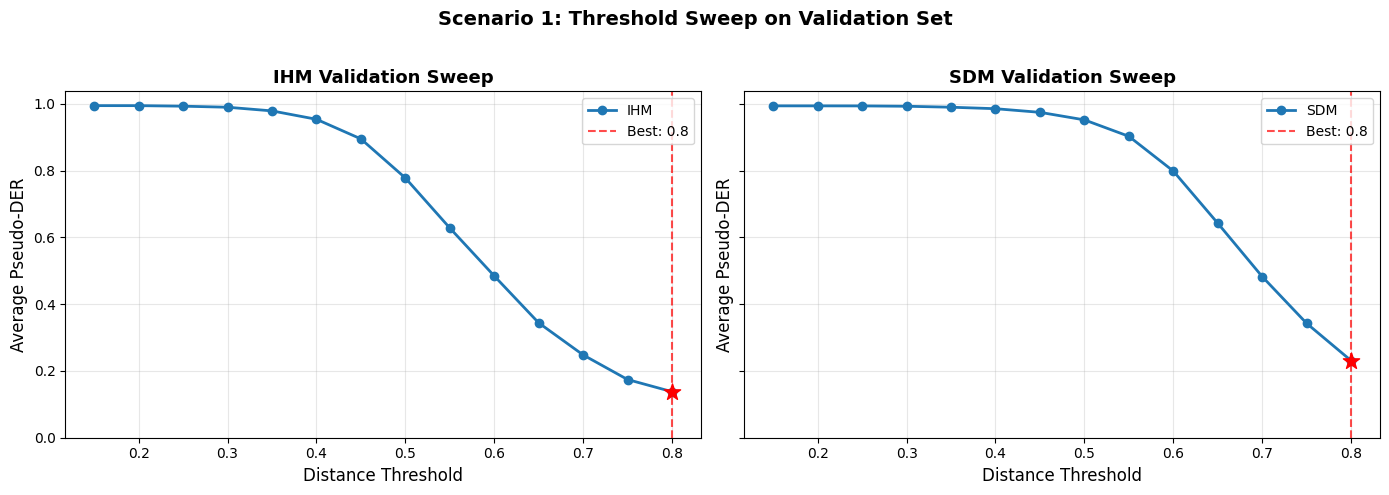

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, mic in enumerate(MIC_CONFIGS):
    ax = axes[idx]
    results = sweep_results[mic]["results"]
    
    thresholds = [d["threshold"] for d in results["sweep"]]
    ders = [d["avg_pseudo_der"] for d in results["sweep"]]
    
    ax.plot(thresholds, ders, 'o-', linewidth=2, markersize=6, label=f'{mic.upper()}')
    
    # Mark best threshold
    best_t = sweep_results[mic]["best_threshold"]
    best_der = sweep_results[mic]["best_pseudo_der"]
    ax.axvline(best_t, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_t}')
    ax.scatter([best_t], [best_der], color='red', s=150, zorder=5, marker='*')
    
    ax.set_xlabel("Distance Threshold", fontsize=12)
    ax.set_ylabel("Average Pseudo-DER", fontsize=12)
    ax.set_title(f"{mic.upper()} Validation Sweep", fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_ylim(bottom=0)

plt.suptitle("Scenario 1: Threshold Sweep on Validation Set", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save figure
fig_path = project_root / "results" / "visualizations" / "threshold_sweep_validation.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Saved figure: {fig_path}")
plt.show()

## 10. Save Sweep Results to JSON

Persist the sweep results so you can reference them later.

In [10]:
sweep_output_path = project_root / "results" / "threshold_sweep_validation.json"
sweep_output_path.parent.mkdir(parents=True, exist_ok=True)

# Prepare serializable output
output_data = {
    "timestamp": str(np.datetime64('now')),
    "split": SPLIT,
    "num_meetings": len(validation_meetings),
    "candidate_thresholds": CANDIDATE_THRESHOLDS,
    "linkage_method": LINKAGE_METHOD,
    "metric": METRIC,
    "results": {},
}

for mic in MIC_CONFIGS:
    results = sweep_results[mic]["results"]
    # Convert numpy types to Python native types for JSON serialization
    sweep_details = []
    for detail in results["sweep"]:
        sweep_details.append({
            "threshold": float(detail["threshold"]),
            "avg_pseudo_der": float(detail["avg_pseudo_der"]),
            "per_meeting_der": [float(d) for d in detail["per_meeting_der"]],
        })
    
    output_data["results"][mic] = {
        "best_threshold": float(sweep_results[mic]["best_threshold"]),
        "best_pseudo_der": float(sweep_results[mic]["best_pseudo_der"]),
        "sweep": sweep_details,
    }

with open(sweep_output_path, "w", encoding="utf-8") as f:
    json.dump(output_data, f, indent=2)

print(f"Saved sweep results to: {sweep_output_path}")
print(f"\n{'='*60}")
print("SUMMARY: Best Thresholds")
print(f"{'='*60}")
for mic in MIC_CONFIGS:
    bt = sweep_results[mic]["best_threshold"]
    bd = sweep_results[mic]["best_pseudo_der"]
    print(f"  {mic.upper()}: threshold={bt:.4f}, pseudo-DER={bd:.4f}")

Saved sweep results to: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/results/threshold_sweep_validation.json

SUMMARY: Best Thresholds
  IHM: threshold=0.8000, pseudo-DER=0.1378
  SDM: threshold=0.8000, pseudo-DER=0.2309


## 11. Apply Best Thresholds to Experiment Configs

Now update the Scenario 1 experiment configs with the validated thresholds and run on the test set.

**Run this cell to update the configs automatically:**

In [11]:
def update_scenario1_config(config_path: Path, new_threshold: float) -> dict:
    """Update the distance_threshold in a Scenario 1 config file."""
    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)
    
    old_threshold = config["diarization"].get("distance_threshold")
    config["diarization"]["distance_threshold"] = new_threshold
    
    # Remove the placeholder note if present
    if "note" in config["diarization"]:
        del config["diarization"]["note"]
    
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(config, f, indent=2)
    
    return {
        "config_path": str(config_path),
        "old_threshold": old_threshold,
        "new_threshold": new_threshold,
    }

config_dir = project_root / "experiments" / "configs"

updates = []
for mic in MIC_CONFIGS:
    config_path = config_dir / f"scenario1_{mic}.json"
    best_t = sweep_results[mic]["best_threshold"]
    update = update_scenario1_config(config_path, best_t)
    updates.append(update)
    print(f"Updated {config_path.name}: threshold {update['old_threshold']} → {update['new_threshold']}")

print(f"\n{'='*60}")
print("Config files updated. Next steps:")
print(f"{'='*60}")
print("1. Re-run Scenario 1 on the test set:")
print("   .venv/bin/python experiments/run_experiment.py \\")
print("       --config experiments/configs/scenario1_ihm.json\\")
print("   .venv/bin/python experiments/run_experiment.py \\")
print("       --config experiments/configs/scenario1_sdm.json\\")
print("\n2. Or run all experiments:")
print("   .venv/bin/python experiments/run_all_experiments.py \\")
print("       --scenario scenario1\\")

Updated scenario1_ihm.json: threshold 0.35 → 0.8
Updated scenario1_sdm.json: threshold 0.4 → 0.8

Config files updated. Next steps:
1. Re-run Scenario 1 on the test set:
   .venv/bin/python experiments/run_experiment.py \
       --config experiments/configs/scenario1_ihm.json\
   .venv/bin/python experiments/run_experiment.py \
       --config experiments/configs/scenario1_sdm.json\

2. Or run all experiments:
   .venv/bin/python experiments/run_all_experiments.py \
       --scenario scenario1\


## 12. (Optional) Run Scenario 1 on Test Set from Notebook

If you want to run the test experiments directly from this notebook instead of the terminal:

In [12]:
from experiments.run_experiment import run_experiment

# Run Scenario 1 on test set for both mic configurations
test_results = {}
for mic in MIC_CONFIGS:
    config_path = config_dir / f"scenario1_{mic}.json"
    print(f"\n{'='*60}")
    print(f"Running test experiment: {config_path.name}")
    print(f"{'='*60}")
    
    result = run_experiment(
        config_path=config_path,
        fail_fast=False,
        use_cached_asr=True,      # Reuse existing ASR
        use_cached_embeddings=True,  # Reuse existing embeddings
    )
    
    test_results[mic] = result
    summary = result.get("summary", {})
    print(f"\nResult: {summary.get('num_completed')}/{summary.get('num_meetings_total')} meetings completed")
    print(f"Mean DER: {summary.get('der', {}).get('mean')}")
    print(f"Mean WER: {summary.get('wer_integrated', {}).get('mean')}")
    print(f"Output: {result['output_dir']}")

print(f"\n{'='*60}")
print("All test experiments complete!")
print(f"{'='*60}")

2026-06-16 22:41:41 | INFO     | experiment.scenario1_ihm | Experiment started: scenario1_ihm
2026-06-16 22:41:41,926 | INFO | Experiment started: scenario1_ihm
2026-06-16 22:41:41 | INFO     | experiment.scenario1_ihm | Config path: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/experiments/configs/scenario1_ihm.json
2026-06-16 22:41:41,927 | INFO | Config path: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/experiments/configs/scenario1_ihm.json
2026-06-16 22:41:41 | INFO     | experiment.scenario1_ihm | Output directory: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/notebooks/results/experiments/scenario1_ihm_20260616_224141
2026-06-16 22:41:41,927 | INFO | Output directory: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/notebooks/results/experiments/scenario1_ihm_20260616_224141
2026-06-16 22:41:41 | INFO     | experiment.scenario1_ihm | Saved resolved config: /home/ikkjo/projec


Running test experiment: scenario1_ihm.json


FileNotFoundError: Annotations directory not found: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/notebooks/data/processed

---

## Appendix: Troubleshooting

### If validation embeddings fail to generate
- Check that `HF_CACHE_DIR` points to the correct HuggingFace cache directory
- Ensure the AMI dataset is fully downloaded (validation split meetings exist)
- Check GPU availability: `get_device()` should return `cuda` for reasonable speed

### If the sweep crashes
- Verify that all validation meetings have valid annotations with `speaker_id` and `begin_time`/`end_time` fields
- Check that embedding arrays have shape `(N, D)` where `N` matches the number of segments

### If the best threshold is at an extreme (0.15 or 0.80)
- The candidate range may be too narrow. Extend `CANDIDATE_THRESHOLDS` to include more values
- For example, add `[0.10, 0.12, 0.14, 0.85, 0.90]`

### If pseudo-DER is very high even at the best threshold
- This may indicate that the embedding model (ECAPA-TDNN, pretrained on VoxCeleb) does not generalize well to AMI
- Fine-tuning the embedding model on AMI data would be the next step (see project spec requirement 3)